## Aim

Given a vector file (geojson or other), the exact tile grid IDs of Sentinel 2 that intersect with it are obtained.

The tiling grid in geojson can be found on [Zenodo](https://zenodo.org/records/10998972).

The code below is run in Google Colab.

## Importing the Python packages

In [64]:
from pathlib import Path
from typing import List, Literal

import folium
import geopandas as gpd
from geopandas import GeoDataFrame as GDF

## Reading in the data

The original geojson data for Brussels is obtained from [here](https://opendata.brussels.be/explore/dataset/limites-administratives-des-communes-en-region-de-bruxelles-capitale/export/?disjunctive.national_code&disjunctive.urbis_id&disjunctive.name_fr&disjunctive.name_nl&location=11,50.83885,4.36302&basemap=jawg.sunny).

Using the Topology Checker in QGIS, we noticed that there were lots of errors in the form of gaps, overlaps and multi-part geometries. Hence, Mapshaper was used to resolve this using the "clean" command. Still, some errors related to "multipart feature" remained but these were not critical for dissolving (please see below) the geojson file.

These data are then uploaded here in Github:

In [65]:
## root path
root_path = 'https://github.com/EllenB/eopf/releases/download/data/'


In [66]:
file_brussels = 'limites-administratives-des-communes-en-region-de-bruxelles-capitale_clean.geojson'

In [67]:
brussels_link = root_path + file_brussels
brussels_link

'https://github.com/EllenB/eopf/releases/download/data/limites-administratives-des-communes-en-region-de-bruxelles-capitale_clean.geojson'

In [68]:
brussels_link = root_path + file_brussels
brussels_link

'https://github.com/EllenB/eopf/releases/download/data/limites-administratives-des-communes-en-region-de-bruxelles-capitale_clean.geojson'

In [69]:
!wget -O brussels_boundary.geojson \
$brussels_link

--2026-03-09 06:48:29--  https://github.com/EllenB/eopf/releases/download/data/limites-administratives-des-communes-en-region-de-bruxelles-capitale_clean.geojson
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/1146031685/3cede398-99e3-45c9-bfab-57d49b2e6ade?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-09T07%3A39%3A43Z&rscd=attachment%3B+filename%3Dlimites-administratives-des-communes-en-region-de-bruxelles-capitale_clean.geojson&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-09T06%3A39%3A18Z&ske=2026-03-09T07%3A39%3A43Z&sks=b&skv=2018-11-09&sig=edBv0xIChlI8zqU94%2Fcl4zWahMEeedj4P29quRJimXY%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXN

<Axes: >

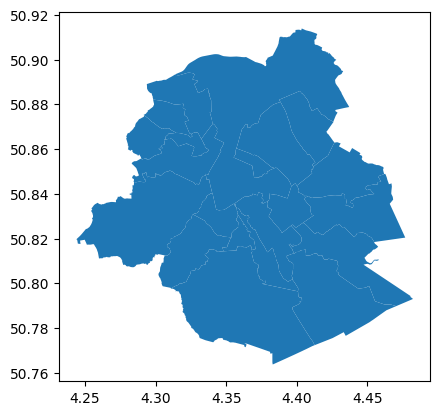

In [70]:
brussels_gdf = gpd.read_file('/content/brussels_boundary.geojson')
brussels_gdf.plot()

First, we dissolve the file:

<Axes: >

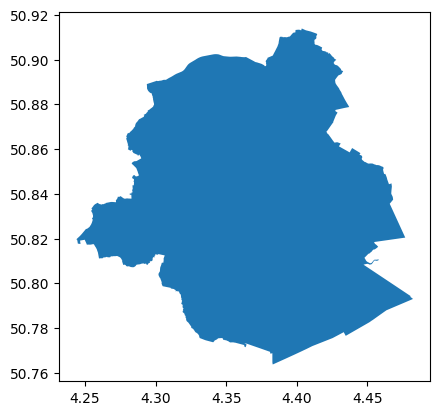

In [71]:
brussels_gdf_dissolved = brussels_gdf.dissolve()
brussels_gdf_dissolved.plot()

In [72]:
brussels_gdf_dissolved

,geometry,ogc_fid,inspire_id,national_code,urbis_id,name_fr,name_nl,versionid,re_id,geo_point_2d
0,"POLYGON ((4.41097 50.77191, 4.40671 50.77059, ...",6,BE.BRUSSELS.BRIC.ADM.MU.64,21018,8800,Woluwe-Saint-Lambert,Sint-Lambrechts-Woluwe,1,1,"{'lon': 4.431540636139221, 'lat': 50.847889597..."


Download this file:

In [ ]:
brussels_gdf_dissolved.to_file('brussels_dissolved.geojson', driver="GeoJSON")

The geojson of the Sentinel 2 tile grid:

In [73]:
path_s2_grid = root_path + 'sentinel2_tiling_grid_wgs84.geojson'

In [74]:
s2_grid = gpd.read_file(path_s2_grid)

In [75]:
s2_grid.head()

,Name,geometry
0,01CCV,"MULTIPOLYGON Z (((180 -73.05974 0, 176.86462 -..."
1,01CCV,"MULTIPOLYGON Z (((-180 -72.07333 0, -179.62744..."
2,01CDH,"MULTIPOLYGON Z (((180 -83.80855 0, 174.71288 -..."
3,01CDH,"MULTIPOLYGON Z (((-180 -82.8259 0, -176.29744 ..."
4,01CDJ,"MULTIPOLYGON Z (((180 -82.91344 0, 175.74819 -..."


In [76]:
print(f'There are {s2_grid.shape[0]} tiles in the Sentinel 2 tile grid')

There are 56984 tiles in the Sentinel 2 tile grid


## Function to extract tile ID

Next, a function is defined that given a geopandas dataframe the Sentinel 2 tiles the dataframe intersects with is given.

In [77]:
def extract_s2_tiles(
    aoi_gdf: GDF,
    tiles_gdf: GDF,
    predicate: Literal["within", "intersects"] = "within"
  ) -> List[str]:
  """
  Extract Sentinel-2 tile IDs related to an AOI.

  Parameters
  ----------
  aoi_gdf : GeoDataFrame
        GeoDataFrame of the AOI.
  tiles_gdf : GeoDataFrame
        GeoDataFrame of the Sentinel-2 tile grid.

  Returns
  -------
  List[str]
        List of tile IDs that intersect the AOI.

  """
  ## Check for same crs
  if aoi_gdf.crs != tiles_gdf.crs:
        print(f'CRS mismatch detected! Reprojecting AOI from {aoi_gdf.crs} to {tiles_gdf.crs}')
        aoi_gdf = aoi_gdf.to_crs(tiles_gdf.crs)

  polys_in_polys = gpd.sjoin(aoi_gdf, tiles_gdf, predicate=predicate, how='left')
  return polys_in_polys['Name'].to_list()

## Examples for extracting tiles

In [78]:
tiles_brussels_within = extract_s2_tiles(brussels_gdf_dissolved, s2_grid)
print(f'The area of interest falls in the following Sentinel 2 tiles: {tiles_brussels_within}')

The area of interest falls in the following Sentinel 2 tiles: ['31UES']


In [79]:
tiles_brussels_intersects = extract_s2_tiles(brussels_gdf_dissolved, s2_grid, predicate = 'intersects')
print(f'The area of intersects with the following Sentinel 2 tiles: {tiles_brussels_intersects}')

The area of intersects with the following Sentinel 2 tiles: ['31UES', '31UFS']


## Folium plots

In [80]:
def extract_center_lat_lon(gdf:GDF) -> list[float, float]:
  """
  Extract the center point in latitude and longitude of a given a given
  geopandas dataframe

  Parameters
  ----------
  gdf : GeoDataFrame
    GeoDataFrame in EPSG:4326.

  Returns
  -------
  Tuple[float, float]
      (latitude, longitude) of the center.
  """
  minx, miny, maxx, maxy = gdf.total_bounds

  lon_center = (minx + maxx) / 2
  lat_center = (miny + maxy) / 2

  return [lat_center, lon_center]


Initiate the map:

In [81]:
center = extract_center_lat_lon(brussels_gdf_dissolved)
print(center)

[np.float64(50.83879069944305), np.float64(4.363018144646041)]


In [ ]:
m = folium.Map(center, zoom_start=7)
m

In [82]:
def extract_gdf_tiles(
    gdf:GDF,
    list_tiles: List
) -> GDF:
  gdf_tiles_short = gdf[gdf['Name'].isin(list_tiles)]
  return gdf_tiles_short

In [83]:
tiles_brussels = extract_gdf_tiles(s2_grid, tiles_brussels_intersects)
tiles_brussels

,Name,geometry
29489,31UES,"MULTIPOLYGON Z (((2.99971 51.45118 0, 4.57954 ..."
29498,31UFS,"MULTIPOLYGON Z (((4.43888 51.44235 0, 6.01703 ..."


In [ ]:
bordersStyle = {
    "color": "blue",
    "weight": 1,
    "fillColor": "pink",
    "fillOpacity": 0.05,
}

m = folium.Map(location=center, zoom_start=9)

folium.GeoJson(
    brussels_gdf_dissolved,
    name="Brussels AOI",
    style_function=lambda _: {
        "color": "black",
        "weight": 2,
        "fillOpacity": 0.1,
    },
).add_to(m)

folium.GeoJson(
    tiles_brussels,
    name="Sentinel-2 tiles",
    style_function=lambda _: bordersStyle,
    tooltip=folium.GeoJsonTooltip(fields=["Name"]),
).add_to(m)

folium.LayerControl().add_to(m)
m

One can see that Brussels is fully  within the tile **31UES**.

Since the code is commented in the past few cells (as this is better to upload less big files in Github), you can find some images here. The left one shows how you can toggle between the geojson of Brussels and the layers for the two tiles for which there is an overlap with the Brussels geometry.

In [63]:
from IPython.display import Image, display, HTML

url1 = "https://raw.githubusercontent.com/EllenB/eopf/main/images/brussels_folium.JPG"
url2 = "https://raw.githubusercontent.com/EllenB/eopf/main/images/brussels_folium_2.JPG"  # replace if needed

display(HTML(f"""
<div style="display:flex; gap:20px;">
  <img src="{url1}" width="500">
  <img src="{url2}" width="500">
</div>
"""))


## References

https://geopandas.org/en/stable/docs/reference/api/geopandas.sjoin.html

https://python-visualization.github.io/folium/latest/user_guide/geojson/geojson.html#styling

https://python-visualization.github.io/folium/latest/user_guide/geojson/geojson_popup_and_tooltip.html

[Sentinel-2 Tiling Grid (WGS84) in geojson format](https://zenodo.org/records/10998972)